# Main Research Pipeline

This notebook orchestrates:
- data loading
- feature generation
- preprocessing
- baseline modeling
- walk-forward validation
- experiment logging

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import get_default_config
from src.data_utils import (
    load_market_data,
    summarize_market_data,
    get_available_fields,
    get_field_panel,
)
from src.features import (
    build_features_from_config,
    build_label_next_return,
)
from src.preprocessing import (
    preprocess_features,
    align_features_and_label,
    slice_features_by_date,
)
from src.models import (
    make_model,
    fit_model,
    fit_and_predict,
    stacked_predictions_to_panel,
)
from src.validation import run_walk_forward_validation
from src.evaluation import (
    get_hourly_risk_free_rate,
    analyze_expected_returns,
)

from src.persistence import (
    save_final_artifacts,
    load_final_artifacts,
)

In [28]:
config = get_default_config()

config.experiment_name = "baseline_elastic_net_walk_forward"

# Feature choices
config.features.feature_set_name = "baseline"
config.features.raw_fields = [
    "return",
    "close",
    "nb_trades",
    "volume_usd",
    "funding_rate",
    "open_interest_value",
]
config.features.feature_styles = [
    "level",
    "delta_1",
    "shift_1",
    "shift_6",
    "mean_24",
    "std_24",
]

# Model choice
config.model.model_name = "elastic_net"
config.model.params = {
    "alpha": 1e-5,
    "l1_ratio": 0.5,
    "fit_intercept": True,
    "tol": 2e-2,
    "selection": "random",
    "max_iter": 500,
    "random_state": config.random_seed,
}

# Walk-forward settings
config.walk_forward.enabled = True
config.walk_forward.retrain_frequency = "ME"
config.walk_forward.train_window_days = 365
config.walk_forward.validation_window_days = 31
config.walk_forward.min_folds_before_start = 2
config.walk_forward.prediction_delay_hours = 1

# Evaluation
config.evaluation.transaction_cost = 0.0
config.evaluation.evaluation_lags = [0, 1, 2, 3, 6, 12]
config.evaluation.plot_option = "matplotlib"

config

ExperimentConfig(experiment_name='baseline_elastic_net_walk_forward', random_seed=0, paths=PathsConfig(data_dir='data/all/', artifacts_dir='artifacts', results_dir='results', in_sample_filename='data_in_sample.csv', test_filename='data_test.csv'), data=DataConfig(datetime_col=None, index_col=0, header_rows=[0, 1]), dates=DateConfig(start_date_train='2023-01-24', last_date_train='2024-01-24', start_date_validate='2024-01-25', last_date_validate='2024-07-24'), evaluation=EvalConfig(risk_free_rate_annual=0.05, transaction_cost=0.0, evaluation_lags=[0, 1, 2, 3, 6, 12], plot_option='matplotlib', annualization_factor=8760), features=FeatureConfig(feature_set_name='baseline', raw_fields=['return', 'close', 'nb_trades', 'volume_usd', 'funding_rate', 'open_interest_value'], feature_styles=['level', 'delta_1', 'shift_1', 'shift_6', 'mean_24', 'std_24'], use_engineered_features=False, engineered_feature_prefix='feature', max_nb_features=20, pct_engineered_features=0.25, fillna_value=0.0), preproc

In [29]:
config_path = f"artifacts/{config.experiment_name}_config.json"
config.to_json(config_path)

print(f"Saved config to: {config_path}")

Saved config to: artifacts/baseline_elastic_net_walk_forward_config.json


In [30]:
data = load_market_data(
    filepath=f"{config.paths.data_dir}/{config.paths.in_sample_filename}",
    index_col=config.data.index_col,
    header_rows=config.data.header_rows,
)

summary = summarize_market_data(data)
display(summary)

n_timestamps                     13152
n_columns_total                   4521
n_fields                            11
n_instruments                      411
start_date         2023-01-24 00:00:00
end_date           2024-07-24 23:00:00
dtype: object

In [31]:
fields = get_available_fields(data)
print("Available fields:")
print(fields)

returns_panel = get_field_panel(data, "return")
print("\nReturns panel shape:", returns_panel.shape)

returns_panel.head()

Available fields:
['open', 'high', 'low', 'close', 'nb_trades', 'volume_coin', 'volume_usd', 'open_interest', 'open_interest_value', 'funding_rate', 'return']

Returns panel shape: (13152, 411)


,VANRY,EGLD,BTS,KEY,HIPPO,FRONT,BLZ,ETH,USUAL,MEME,...,CKB,ATOM,AUCTION,ARKM,POPCAT,PNUT,SPX,AXS,YFI,MDT
2023-01-24 00:00:00,NaN,-0.006325,NaN,NaN,NaN,NaN,0.002640,-0.000792,NaN,NaN,...,NaN,-0.004116,NaN,NaN,NaN,NaN,NaN,-0.013171,-0.001795,NaN
2023-01-24 01:00:00,NaN,-0.002501,NaN,NaN,NaN,NaN,-0.008591,0.003331,NaN,NaN,...,NaN,0.002296,NaN,NaN,NaN,NaN,NaN,-0.025383,0.002440,NaN
2023-01-24 02:00:00,NaN,0.009799,NaN,NaN,NaN,NaN,0.019287,0.003878,NaN,NaN,...,NaN,0.008781,NaN,NaN,NaN,NaN,NaN,0.007645,0.014092,NaN
2023-01-24 03:00:00,NaN,0.000451,NaN,NaN,NaN,NaN,-0.006445,-0.001733,NaN,NaN,...,NaN,0.005147,NaN,NaN,NaN,NaN,NaN,0.000000,-0.000253,NaN
2023-01-24 04:00:00,NaN,0.002481,NaN,NaN,NaN,NaN,0.014905,0.002292,NaN,NaN,...,NaN,0.006401,NaN,NaN,NaN,NaN,NaN,0.014424,0.006065,NaN


In [32]:
features = build_features_from_config(data, config.features)

print("Raw feature matrix shape:", features.shape)
display(features.head())

Raw feature matrix shape: (2858559, 36)


return_level  return_delta_1  return_shift_1  return_shift_6  \
2023-01-24 EGLD     -0.006325             NaN             NaN             NaN   
           BLZ       0.002640             NaN             NaN             NaN   
           ETH      -0.000792             NaN             NaN             NaN   
           AAVE      0.000462             NaN             NaN             NaN   
           ALGO     -0.000800             NaN             NaN             NaN   

                 return_mean_24  return_std_24  close_level  close_delta_1  \
2023-01-24 EGLD       -0.006325            NaN     43.99000            NaN   
           BLZ         0.002640            NaN      0.07217            NaN   
           ETH        -0.000792            NaN   1626.90000            NaN   
           AAVE        0.000462            NaN     86.66000            NaN   
           ALGO       -0.000800            NaN      0.24980            NaN   

                 close_shift_1  close_shift_6  ...  funding_rate_shift_1  \
2023-01-24 EGLD            NaN            NaN  ...                   NaN   
           BLZ             NaN            NaN  ...                   NaN   
           ETH             NaN            NaN  ...                   NaN   
           AAVE            NaN            NaN  ...                   NaN   
           ALGO            NaN            NaN  ...                   NaN   

                 funding_rate_shift_6  funding_rate_mean_24  \
2023-01-24 EGLD                   NaN                   NaN   
           BLZ                    NaN                   NaN   
           ETH                    NaN                   NaN   
           AAVE                   NaN                   NaN   
           ALGO                   NaN                   NaN   

                 funding_rate_std_24  open_interest_value_level  \
2023-01-24 EGLD                  NaN               1.276026e+07   
           BLZ                   NaN               3.613338e+06   
           ETH                   NaN               1.749468e+09   
           AAVE                  NaN               2.554519e+07   
           ALGO                  NaN               1.349624e+07   

                 open_interest_value_delta_1  open_interest_value_shift_1  \
2023-01-24 EGLD                          NaN                          NaN   
           BLZ                           NaN                          NaN   
           ETH                           NaN                          NaN   
           AAVE                          NaN                          NaN   
           ALGO                          NaN                          NaN   

                 open_interest_value_shift_6  open_interest_value_mean_24  \
2023-01-24 EGLD                          NaN                 1.276026e+07   
           BLZ                           NaN                 3.613338e+06   
           ETH                           NaN                 1.749468e+09   
           AAVE                          NaN                 2.554519e+07   
           ALGO                          NaN                 1.349624e+07   

                 open_interest_value_std_24  
2023-01-24 EGLD                         NaN  
           BLZ                          NaN  
           ETH                          NaN  
           AAVE                         NaN  
           ALGO                         NaN  

[5 rows x 36 columns]

In [33]:
features_processed = preprocess_features(features, config.preprocessing)

print("Processed feature matrix shape:", features_processed.shape)
display(features_processed.head())

Processed feature matrix shape: (2858559, 36)


return_level  return_delta_1  return_shift_1  return_shift_6  \
2023-01-24 EGLD     -1.158570             0.0             0.0             0.0   
           BLZ       1.042713             0.0             0.0             0.0   
           ETH       0.115857             0.0             0.0             0.0   
           AAVE      0.509771             0.0             0.0             0.0   
           ALGO      0.092686             0.0             0.0             0.0   

                 return_mean_24  return_std_24  close_level  close_delta_1  \
2023-01-24 EGLD       -1.158570            0.0     1.320769            0.0   
           BLZ         1.042713            0.0    -1.089055            0.0   
           ETH         0.115857            0.0     1.668339            0.0   
           AAVE        0.509771            0.0     1.436625            0.0   
           ALGO        0.092686            0.0    -0.486599            0.0   

                 close_shift_1  close_shift_6  ...  funding_rate_shift_1  \
2023-01-24 EGLD            0.0            0.0  ...                   0.0   
           BLZ             0.0            0.0  ...                   0.0   
           ETH             0.0            0.0  ...                   0.0   
           AAVE            0.0            0.0  ...                   0.0   
           ALGO            0.0            0.0  ...                   0.0   

                 funding_rate_shift_6  funding_rate_mean_24  \
2023-01-24 EGLD                   0.0                   0.0   
           BLZ                    0.0                   0.0   
           ETH                    0.0                   0.0   
           AAVE                   0.0                   0.0   
           ALGO                   0.0                   0.0   

                 funding_rate_std_24  open_interest_value_level  \
2023-01-24 EGLD                  0.0                   0.625627   
           BLZ                   0.0                  -1.158569   
           ETH                   0.0                   1.691511   
           AAVE                  0.0                   0.973198   
           ALGO                  0.0                   0.695141   

                 open_interest_value_delta_1  open_interest_value_shift_1  \
2023-01-24 EGLD                          0.0                          0.0   
           BLZ                           0.0                          0.0   
           ETH                           0.0                          0.0   
           AAVE                          0.0                          0.0   
           ALGO                          0.0                          0.0   

                 open_interest_value_shift_6  open_interest_value_mean_24  \
2023-01-24 EGLD                          0.0                     0.625627   
           BLZ                           0.0                    -1.158569   
           ETH                           0.0                     1.691511   
           AAVE                          0.0                     0.973198   
           ALGO                          0.0                     0.695141   

                 open_interest_value_std_24  
2023-01-24 EGLD                         0.0  
           BLZ                          0.0  
           ETH                          0.0  
           AAVE                         0.0  
           ALGO                         0.0  

[5 rows x 36 columns]

In [34]:
label_train = build_label_next_return(
    data=data,
    start_date=config.dates.start_date_train,
    end_date=config.dates.last_date_train,
)

print("Training label shape:", label_train.shape)
display(label_train.head())

Training label shape: (1716459,)


2023-01-24  EGLD   -0.002501
            BLZ    -0.008591
            ETH     0.003331
            AAVE    0.000000
            ALGO    0.009608
Name: label_next_return, dtype: float64

In [35]:
X_train, y_train = align_features_and_label(features_processed, label_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1716357, 36)
y_train shape: (1716357,)


In [36]:
X_validate = slice_features_by_date(
    features_processed,
    start_date=config.dates.start_date_validate,
    end_date=config.dates.last_date_validate,
)

print("X_validate shape:", X_validate.shape)
display(X_validate.head())

X_validate shape: (1135948, 36)


return_level  return_delta_1  return_shift_1  \
2024-01-25 EGLD       0.055986        0.657831       -0.461881   
           KEY        0.895770        0.055986        0.811791   
           FRONT      0.321917        0.335914        0.013996   
           BLZ       -0.475878        1.021737       -1.021737   
           ETH       -0.965752        1.049730       -1.245680   

                  return_shift_6  return_mean_24  return_std_24  close_level  \
2024-01-25 EGLD        -0.573855        0.307921      -1.357651     1.455626   
           KEY          0.209947        0.545860      -0.013996    -1.553601   
           FRONT       -0.867780       -1.623582      -0.363906    -0.153960   
           BLZ         -1.427638       -0.853780       1.189694    -0.405896   
           ETH          0.727816       -1.385643      -1.609586     1.693565   

                  close_delta_1  close_shift_1  close_shift_6  ...  \
2024-01-25 EGLD        0.055986       1.455626       1.455626  ...   
           KEY         0.895770      -1.553601      -1.553601  ...   
           FRONT       0.321917      -0.153960      -0.153960  ...   
           BLZ        -0.475878      -0.405896      -0.377903  ...   
           ETH        -0.965752       1.693565       1.693565  ...   

                  funding_rate_shift_1  funding_rate_shift_6  \
2024-01-25 EGLD                    0.0                   0.0   
           KEY                     0.0                   0.0   
           FRONT                   0.0                   0.0   
           BLZ                     0.0                   0.0   
           ETH                     0.0                   0.0   

                  funding_rate_mean_24  funding_rate_std_24  \
2024-01-25 EGLD               0.777046            -0.534489   
           KEY                0.777046            -0.534489   
           FRONT              0.777046            -0.534489   
           BLZ               -1.020363            -0.534489   
           ETH                0.777046            -0.534489   

                  open_interest_value_level  open_interest_value_delta_1  \
2024-01-25 EGLD                    0.321917                    -1.259676   
           KEY                    -0.853780                     1.175697   
           FRONT                  -0.559856                    -0.321917   
           BLZ                     1.273672                    -0.335914   
           ETH                     1.707561                     0.405896   

                  open_interest_value_shift_1  open_interest_value_shift_6  \
2024-01-25 EGLD                      0.335914                     0.307921   
           KEY                      -0.867777                    -0.909766   
           FRONT                    -0.573852                    -0.559856   
           BLZ                       1.273672                     1.273672   
           ETH                       1.707561                     1.707561   

                  open_interest_value_mean_24  open_interest_value_std_24  
2024-01-25 EGLD                      0.293924                    0.979748  
           KEY                      -0.895770                   -1.077723  
           FRONT                    -0.573852                   -1.245679  
           BLZ                       1.259676                    1.287669  
           ETH                       1.707561                    1.707561  

[5 rows x 36 columns]

In [37]:
stacked_preds_baseline = fit_and_predict(
    model_config=config.model,
    X_train=X_train,
    y_train=y_train,
    X_predict=X_validate,
)

pred_panel_baseline = stacked_predictions_to_panel(stacked_preds_baseline)

print("Stacked baseline predictions shape:", stacked_preds_baseline.shape)
print("Panel baseline predictions shape:", pred_panel_baseline.shape)

display(stacked_preds_baseline.head())

Stacked baseline predictions shape: (1135948,)
Panel baseline predictions shape: (4345, 282)


2024-01-25  EGLD     0.000132
            KEY     -0.000032
            FRONT    0.000068
            BLZ      0.000110
            ETH      0.000071
Name: prediction, dtype: float64

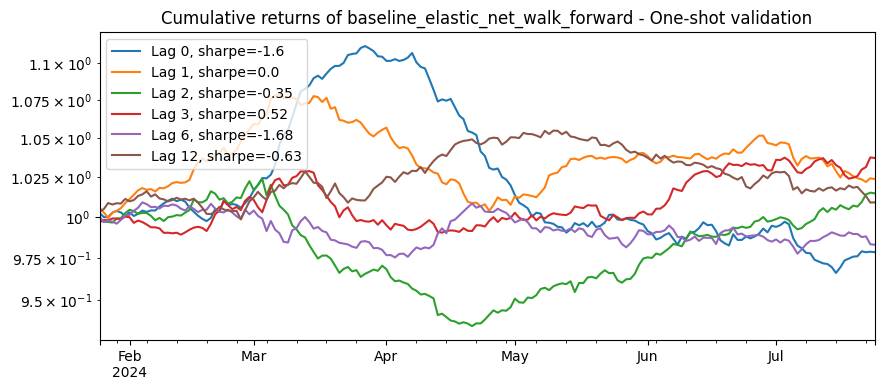

,turnover,sharpe
Statistics,13.18,-1.6


In [38]:
rfr_hourly = get_hourly_risk_free_rate(config.evaluation.risk_free_rate_annual)

baseline_stats = analyze_expected_returns(
    expected_returns=pred_panel_baseline,
    returns=returns_panel.loc[
        config.dates.start_date_validate:config.dates.last_date_validate
    ],
    rfr_hourly=rfr_hourly,
    title=f"{config.experiment_name} - One-shot validation",
    lags=config.evaluation.evaluation_lags,
    tc=config.evaluation.transaction_cost,
    plot_option=config.evaluation.plot_option,
    output_stats=True,
)

display(baseline_stats)

In [39]:
wf_results = run_walk_forward_validation(
    data=data,
    features_processed=features_processed,
    config=config,
    verbose=True,
)

Train: 2022-03-31 00:00:00 -> 2023-03-31 00:00:00
Predict: 2023-03-31 01:00:00 -> 2023-05-01 00:00:00

Train: 2022-04-30 00:00:00 -> 2023-04-30 00:00:00
Predict: 2023-04-30 01:00:00 -> 2023-05-31 00:00:00

Train: 2022-05-31 00:00:00 -> 2023-05-31 00:00:00
Predict: 2023-05-31 01:00:00 -> 2023-07-01 00:00:00

Train: 2022-06-30 00:00:00 -> 2023-06-30 00:00:00
Predict: 2023-06-30 01:00:00 -> 2023-07-31 00:00:00

Train: 2022-07-31 00:00:00 -> 2023-07-31 00:00:00
Predict: 2023-07-31 01:00:00 -> 2023-08-31 00:00:00

Train: 2022-08-31 00:00:00 -> 2023-08-31 00:00:00
Predict: 2023-08-31 01:00:00 -> 2023-10-01 00:00:00

Train: 2022-09-30 00:00:00 -> 2023-09-30 00:00:00
Predict: 2023-09-30 01:00:00 -> 2023-10-31 00:00:00

Train: 2022-10-31 00:00:00 -> 2023-10-31 00:00:00
Predict: 2023-10-31 01:00:00 -> 2023-12-01 00:00:00

Train: 2022-11-30 00:00:00 -> 2023-11-30 00:00:00
Predict: 2023-11-30 01:00:00 -> 2023-12-31 00:00:00

Train: 2022-12-31 00:00:00 -> 2023-12-31 00:00:00
Predict: 2023-12-31 01:

In [40]:
display(wf_results["fold_details"])

,last_date_train_fold,start_date_train_fold,start_date_validate_fold,last_date_validate_fold,n_train_rows,n_validate_rows
0,2023-03-31,2022-03-31,2023-03-31 01:00:00,2023-05-01,253464,129665
1,2023-04-30,2022-04-30,2023-04-30 01:00:00,2023-05-31,378890,135180
2,2023-05-31,2022-05-31,2023-05-31 01:00:00,2023-07-01,514062,137084
3,2023-06-30,2022-06-30,2023-06-30 01:00:00,2023-07-31,646668,140064
4,2023-07-31,2022-07-31,2023-07-31 01:00:00,2023-08-31,786726,145525
5,2023-08-31,2022-08-31,2023-08-31 01:00:00,2023-10-01,932245,148306
6,2023-09-30,2022-09-30,2023-09-30 01:00:00,2023-10-31,1075674,154560
7,2023-10-31,2022-10-31,2023-10-31 01:00:00,2023-12-01,1230222,168628
8,2023-11-30,2022-11-30,2023-11-30 01:00:00,2023-12-31,1393189,177051
9,2023-12-31,2022-12-31,2023-12-31 01:00:00,2024-01-31,1570233,182202


Walk-forward prediction panel shape: (11567, 284)


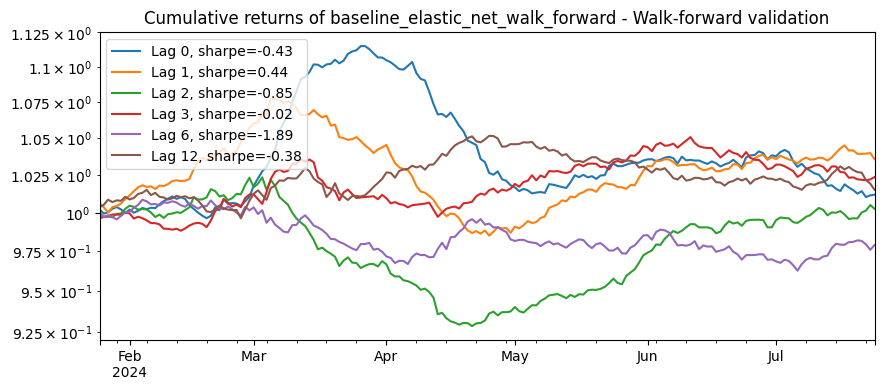

,turnover,sharpe
Statistics,12.15,-0.43


In [41]:
wf_pred_panel = wf_results["predictions_panel"]

print("Walk-forward prediction panel shape:", wf_pred_panel.shape)

wf_stats = analyze_expected_returns(
    expected_returns=wf_pred_panel.loc[
        config.dates.start_date_validate:config.dates.last_date_validate
    ],
    returns=returns_panel.loc[
        config.dates.start_date_validate:config.dates.last_date_validate
    ],
    rfr_hourly=rfr_hourly,
    title=f"{config.experiment_name} - Walk-forward validation",
    lags=config.evaluation.evaluation_lags,
    tc=config.evaluation.transaction_cost,
    plot_option=config.evaluation.plot_option,
    output_stats=True,
)

display(wf_stats)

In [42]:
comparison = pd.concat(
    {
        "one_shot_validation": baseline_stats.iloc[0],
        "walk_forward_validation": wf_stats.iloc[0],
    },
    axis=1,
).T

display(comparison)

,turnover,sharpe
one_shot_validation,13.18,-1.60
walk_forward_validation,12.15,-0.43


In [43]:
run_summary = {
    "experiment_name": config.experiment_name,
    "model_name": config.model.model_name,
    "feature_set_name": config.features.feature_set_name,
    "n_features": features_processed.shape[1],
    "one_shot_sharpe_lag0": baseline_stats.loc["Statistics", "sharpe"],
    "one_shot_turnover": baseline_stats.loc["Statistics", "turnover"],
    "walk_forward_sharpe_lag0": wf_stats.loc["Statistics", "sharpe"],
    "walk_forward_turnover": wf_stats.loc["Statistics", "turnover"],
}

run_summary

{'experiment_name': 'baseline_elastic_net_walk_forward',
 'model_name': 'elastic_net',
 'feature_set_name': 'baseline',
 'n_features': 36,
 'one_shot_sharpe_lag0': np.float64(-1.6),
 'one_shot_turnover': np.float64(13.18),
 'walk_forward_sharpe_lag0': np.float64(-0.43),
 'walk_forward_turnover': np.float64(12.15)}

In [44]:
run_summary_df = pd.DataFrame([run_summary])

summary_path = "results/run_summaries.csv"

try:
    existing = pd.read_csv(summary_path)
    updated = pd.concat([existing, run_summary_df], ignore_index=True)
except FileNotFoundError:
    updated = run_summary_df.copy()

updated.to_csv(summary_path, index=False)

print(f"Saved run summary to: {summary_path}")
display(updated.tail())

Saved run summary to: results/run_summaries.csv


,experiment_name,model_name,feature_set_name,n_features,one_shot_sharpe_lag0,one_shot_turnover,walk_forward_sharpe_lag0,walk_forward_turnover
0,baseline_elastic_net_walk_forward,elastic_net,baseline,36,-1.6,13.18,-0.43,12.15


In [ ]:
final_model = make_model(config.model)
final_model = fit_model(final_model, X_train, y_train)

final_metrics = {
    "one_shot_sharpe_lag0": baseline_stats.loc["Statistics", "sharpe"],
    "one_shot_turnover": baseline_stats.loc["Statistics", "turnover"],
    "walk_forward_sharpe_lag0": wf_stats.loc["Statistics", "sharpe"],
    "walk_forward_turnover": wf_stats.loc["Statistics", "turnover"],
}

artifact_paths = save_final_artifacts(
    model=final_model,
    config=config,
    feature_columns=features_processed.columns.tolist(),
    experiment_name=config.experiment_name,
    artifacts_dir=config.paths.artifacts_dir,
    metrics=final_metrics,
)

artifact_paths